- Deadline of submission: 23h59, 25/05/2026
- Submission [here](https://nextcloud.centralesupelec.fr/s/5gf3jF4tmQwf4ei)
- Please name your submission as `td7_firstname_lastname.ipynb`

# Exercise 1: Auto-Associative Kernel Regression (AAKR)

**Auto-Associative Kernel Regression (AAKR)** is a non-parametric, memory-based regression method widely used in **prognostics and health management** for fault detection and signal reconstruction. Unlike parametric models (e.g., linear regression) that learn explicit coefficients, AAKR makes predictions purely based on **similarity** to stored training observations — called the **memory matrix**.

### How AAKR Works

Given a memory matrix of $n$ training observations $(\mathbf{x}_i, y_i)_{i=1}^{n}$ and a new query point $\mathbf{x}_q$, AAKR predicts $\hat{y}_q$ in three steps:

**Step 1 — Compute distances:** For each training observation, compute the Euclidean distance to the query point:

$$d_i = \|\mathbf{x}_q - \mathbf{x}_i\|_2$$

**Step 2 — Compute kernel weights:** Apply a Gaussian kernel to convert distances into similarity weights:

$$K(\mathbf{x}_q, \mathbf{x}_i) = \exp\left(-\frac{d_i^2}{2h^2}\right)$$

where $h > 0$ is the **bandwidth** parameter. A small $h$ means only very close neighbors contribute; a large $h$ means even distant points have influence.

Normalize the weights so they sum to 1:

$$\tilde{w}_i = \frac{K(\mathbf{x}_q, \mathbf{x}_i)}{\sum_{j=1}^{n} K(\mathbf{x}_q, \mathbf{x}_j)}$$

**Step 3 — Predict:** The prediction is a **weighted average** of the training outputs:

$$\hat{y}_q = \sum_{i=1}^{n} \tilde{w}_i \cdot y_i$$

The key insight is that AAKR does **not** learn a model — it predicts by combining the outputs of similar training observations, weighted by how close they are to the query point.

### The Role of the Bandwidth $h$

The bandwidth $h$ controls the **size of the neighborhood**:
- **Small $h$:** Only the closest training points contribute. The prediction follows the training data closely but may be noisy (overfitting).
- **Large $h$:** Many distant points contribute. The prediction becomes smoother but may miss local patterns (underfitting).

In this exercise, we will:
1. Implement AAKR from scratch and use it to predict on simulated sensor data.
2. Visualize how the prediction is a weighted combination of "neighbor" training points.
3. Explore the effect of the bandwidth parameter $h$ on prediction quality.

First, run the cell below to set up the environment and generate the dataset.

<>:22: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:22: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\oscar\AppData\Local\Temp\ipykernel_35056\3299649963.py:22: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  label="True function: $y = \sin(x)$")


Training data generated: 30 sensor observations


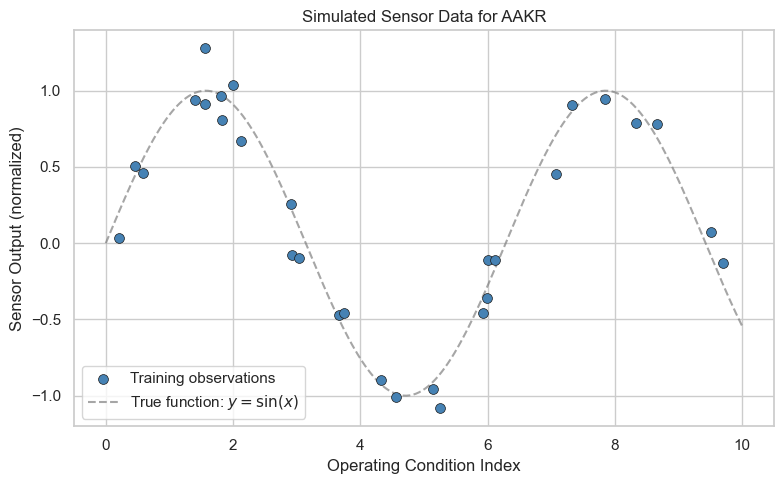

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
np.random.seed(42)

n_train = 30
x_train = np.sort(np.random.uniform(0, 10, n_train))
y_train = np.sin(x_train) + np.random.normal(0, 0.15, n_train)

x_test = np.linspace(0, 10, 200)
y_true = np.sin(x_test)

print(f"Training data generated: {n_train} sensor observations")

plt.figure(figsize=(8, 5))
plt.scatter(x_train, y_train, color="steelblue", s=50, zorder=3,
            label="Training observations", edgecolors="k", linewidth=0.5)
plt.plot(x_test, y_true, color="gray", linestyle="--", alpha=0.7,
         label="True function: $y = \sin(x)$")
plt.xlabel("Operating Condition Index")
plt.ylabel("Sensor Output (normalized)")
plt.title("Simulated Sensor Data for AAKR")
plt.legend()
plt.tight_layout()
plt.show()

## Question 1: Implement AAKR Prediction

The following script Implements the AAKR prediction algorithm in `aakr_predict(x_train, y_train, x_query, h)`:
1. For each query point in `x_query`, computes the Euclidean distance to every training point in `x_train`.
2. Computes Gaussian kernel weights using bandwidth `h`.
3. Normalizes the weights to sum to 1.
4. Returns the weighted average of `y_train`.

In [2]:
def aakr_predict(x_train, y_train, x_query, h):
    distances = np.abs(x_train[np.newaxis, :] - x_query[:, np.newaxis])
    weights = np.exp(-distances**2 / (2 * h**2))
    weights = weights / weights.sum(axis=1, keepdims=True)
    predictions = weights @ y_train
    return predictions

Using `aakr_predict()`, use `h=0.5` to predict on `x_test`, plot the predictions alongside the training data and true function, and compute the **Mean Squared Error (MSE)** between the predictions and the true function `y_true`.

AAKR Prediction (h=0.5) — MSE: 0.0209


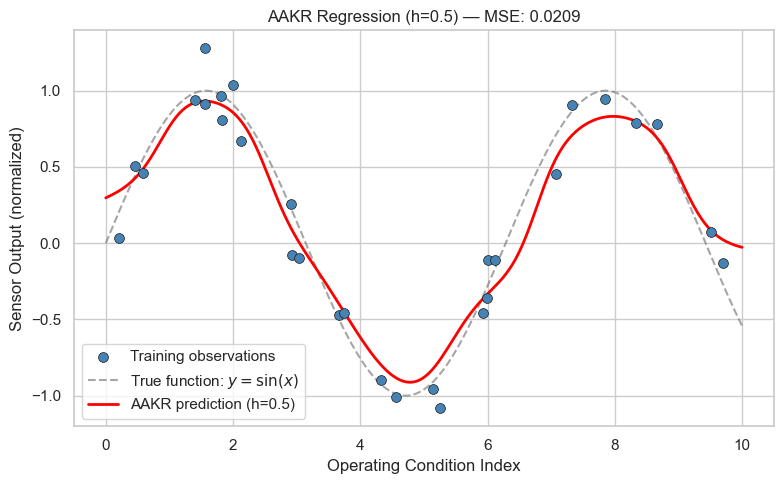

In [3]:
h = .5
y_pred = aakr_predict(x_train, y_train, x_test, h)
mse = np.mean((y_pred - y_true)**2)
print(f"AAKR Prediction (h={h}) — MSE: {mse:.4f}")

plt.figure(figsize=(8, 5))
plt.scatter(x_train, y_train, color="steelblue", s=50, zorder=3,
            label="Training observations", edgecolors="k", linewidth=0.5)
plt.plot(x_test, y_true, color="gray", linestyle="--", alpha=0.7,
         label="True function: $y = \\sin(x)$")
plt.plot(x_test, y_pred, color="red", linewidth=2,
         label=f"AAKR prediction (h={h})")
plt.xlabel("Operating Condition Index")
plt.ylabel("Sensor Output (normalized)")
plt.title(f"AAKR Regression (h={h}) — MSE: {mse:.4f}")
plt.legend()
plt.tight_layout()
plt.show()

How well does the AAKR prediction fit the true function? Why does it capture the overall shape without learning any explicit model?

Answer: With h=0.5 the prediction fits the sine curve quite well, the MSE is around 0.02 which is low. It manages to capture the shape even though it never fits any parameters. The reason is that for each new point it just looks at how close that point is to each training observation, gives more weight to the nearby ones, and takes a weighted average of their outputs. So the shape comes out naturally from the data itself without needing to learn anything explicitly.

## Question 2: Effect of the Bandwidth $h$

The bandwidth $h$ is the single most important parameter in AAKR. Let us explore its effect systematically.

1. Use the values `h_list = [0.1, 0.3, 0.5, 1.0, 2.0, 5.0]`.
2. For each $h$, compute AAKR predictions on `x_test` and the MSE against `y_true`.
3. Create a **2x3 subplot grid** showing the predictions for each $h$, with training data, true function, and predicted curve. Include MSE in each title.

> **Hint:** Use `fig, axes = plt.subplots(2, 3, figsize=(18, 10))` and index with `axes[i // 3, i % 3]`. For each $h$, call `aakr_predict`, compute MSE, and plot. For the weight distribution, compute the normalized weights for $x_q = 5.0$ and use `ax.bar(np.arange(n_train), weights_norm)`. Observe how the bar chart becomes flatter (more uniform) as $h$ increases.

     h      MSE
------------------
  0.10   0.0241
  0.30   0.0181
  0.50   0.0209
  1.00   0.1011
  2.00   0.3047
  5.00   0.4343


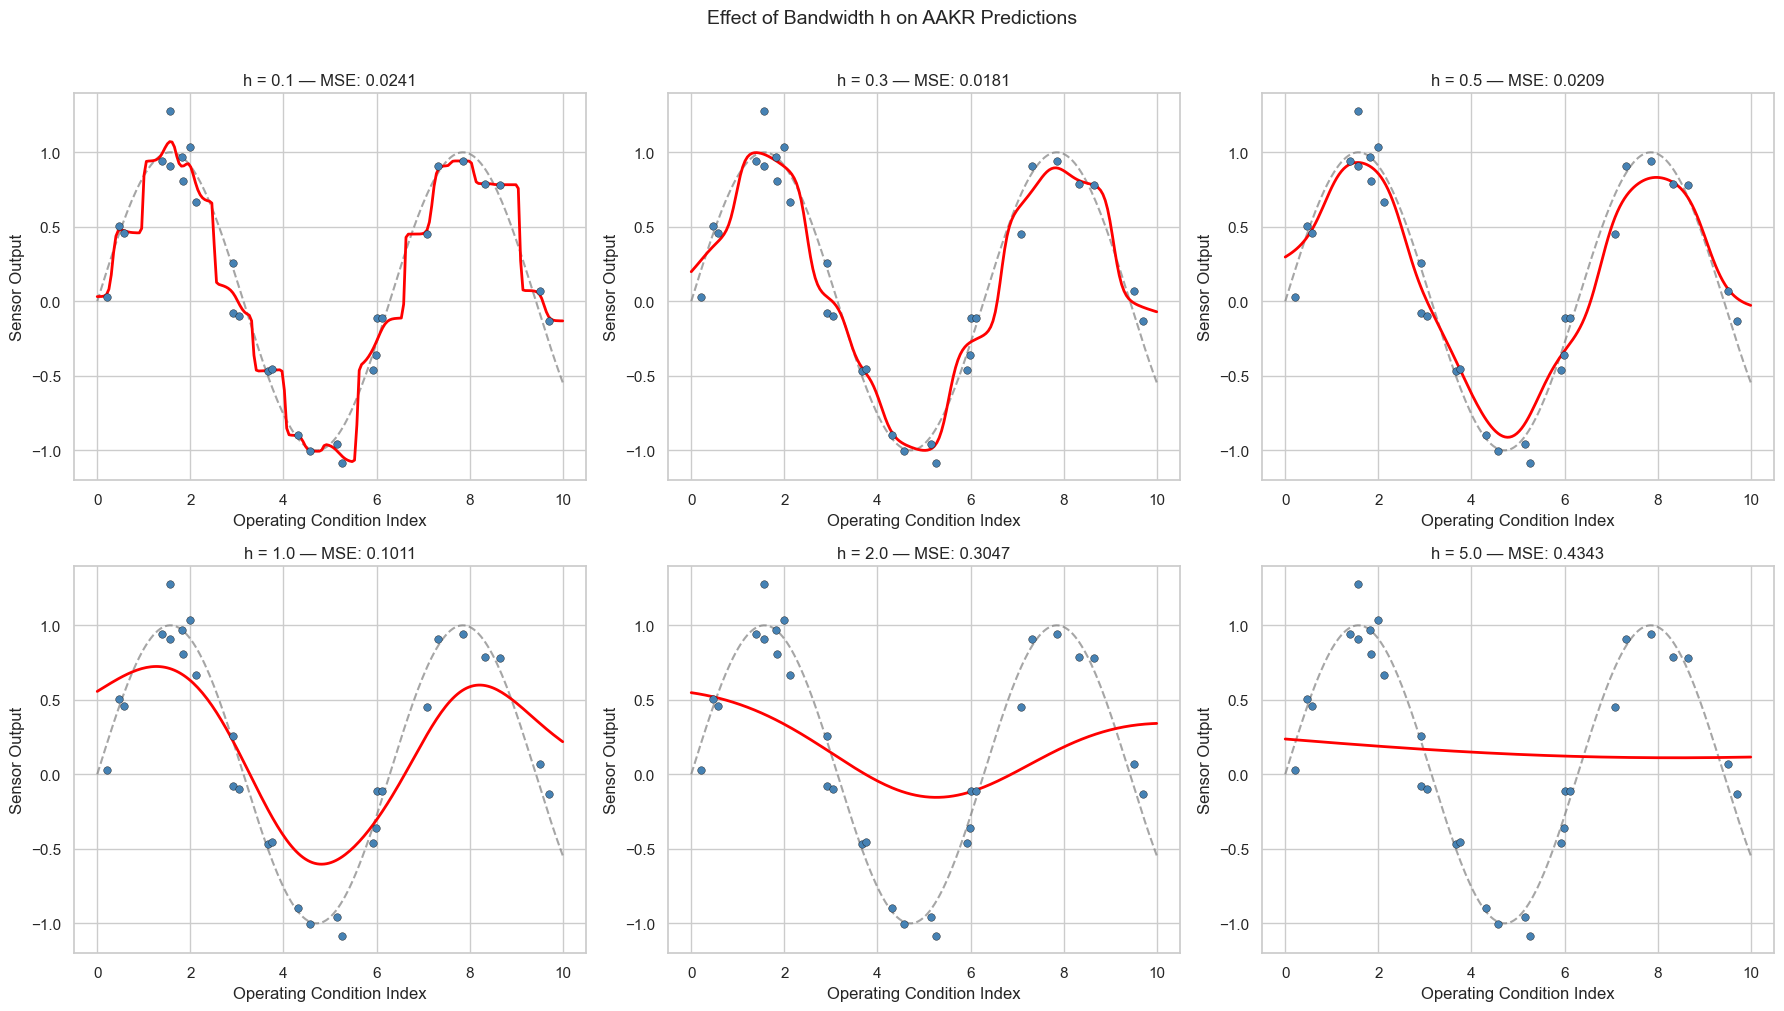

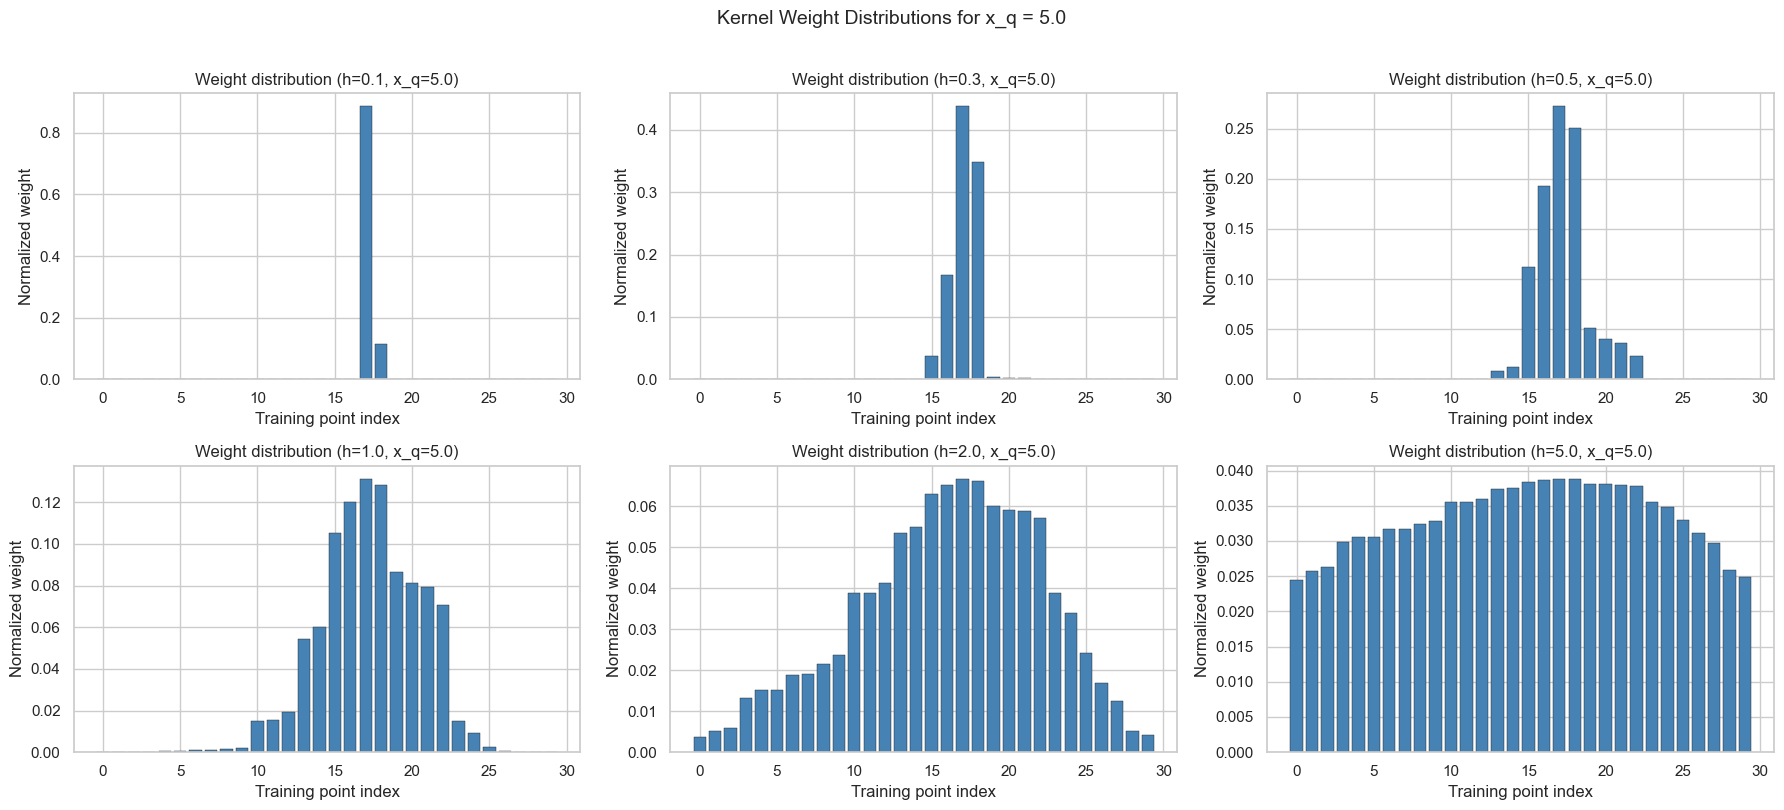

In [4]:
h_list = [0.1, 0.3, 0.5, 1.0, 2.0, 5.0]
x_q = np.array([5.0])

mse_list = []
for h in h_list:
    y_pred_h = aakr_predict(x_train, y_train, x_test, h)
    mse_list.append(np.mean((y_pred_h - y_true)**2))

print(f"{'h':>6s}      MSE")
print("-" * 18)
for h, m in zip(h_list, mse_list):
    print(f"{h:>6.2f}   {m:.4f}")

# Prediction curves
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, (h, mse) in enumerate(zip(h_list, mse_list)):
    ax = axes[i // 3, i % 3]
    y_pred_h = aakr_predict(x_train, y_train, x_test, h)
    ax.scatter(x_train, y_train, color="steelblue", s=30, zorder=3,
               edgecolors="k", linewidth=0.3)
    ax.plot(x_test, y_true, color="gray", linestyle="--", alpha=0.7)
    ax.plot(x_test, y_pred_h, color="red", linewidth=2)
    ax.set_title(f"h = {h} — MSE: {mse:.4f}")
    ax.set_xlabel("Operating Condition Index")
    ax.set_ylabel("Sensor Output")
fig.suptitle("Effect of Bandwidth h on AAKR Predictions", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Weight distributions for x_q = 5.0
fig2, axes2 = plt.subplots(2, 3, figsize=(18, 8))
for i, h in enumerate(h_list):
    ax = axes2[i // 3, i % 3]
    distances_q = np.abs(x_train - x_q[0])
    w = np.exp(-distances_q**2 / (2 * h**2))
    w_norm = w / w.sum()
    ax.bar(np.arange(n_train), w_norm, color="steelblue", edgecolor="k", linewidth=0.3)
    ax.set_title(f"Weight distribution (h={h}, x_q=5.0)")
    ax.set_xlabel("Training point index")
    ax.set_ylabel("Normalized weight")
fig2.suptitle("Kernel Weight Distributions for x_q = 5.0", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Look at both sets of plots above and answer the following:

1. **Small $h$ (e.g., 0.1):** What happens to the prediction curve? Is it smooth or jagged? Why? What does the weight distribution look like?

2. **Large $h$ (e.g., 5.0):** What happens to the prediction? Why does it approach a flat line? How many training points are "active" in the weight distribution?

3. **Optimal $h$:** Which $h$ gives the lowest MSE? Why is there a trade-off between too small and too large $h$?

Answer:

1. With h=0.1 the curve is very spiky. Only the nearest training point gets any meaningful weight, so between training points the prediction drops off sharply. Looking at the weight distribution bar chart, it looks almost like a single spike on the closest point, everything else is basically zero.

2. With h=5.0 the curve becomes nearly flat, close to the mean of all training outputs. When the bandwidth is very large all points get roughly equal weight so the prediction averages everything out and loses all local shape. The bar chart is almost perfectly flat across all 30 points.

3. The lowest MSE is at h=0.3. If h is too small the model reacts too strongly to individual noisy points. If h is too large it ignores all local structure. The best h sits in between where the smoothing is just right.

# Exercise 2: AAKR for Fault Detection

In Exercise 1, we used AAKR as a regression tool. Now we will use it for its primary industrial application: **fault detection**.

### The Principle

The idea is simple but powerful:
1. Build a **memory matrix** from observations known to be **normal** (no faults).
2. For any new observation $\mathbf{x}_q$, AAKR reconstructs what the **normal** signal should look like: $\hat{\mathbf{x}}_q = \text{AAKR}(\mathbf{x}_q)$.
3. Compute the **residual**: $\mathbf{r}_q = \mathbf{x}_q - \hat{\mathbf{x}}_q$.
4. If the residual norm $\|\mathbf{r}_q\|$ exceeds a **threshold**, flag it as a fault.

During normal operation, the observation is close to patterns in the memory matrix, so the residual is small. During a fault, the observation deviates from all normal patterns, producing a **large residual**.

In this exercise, we work with **two correlated sensors**:
- **Sensor 1** (Operating Condition): the driver signal
- **Sensor 2** (System Response): a nonlinear function of Sensor 1 during normal operation

During faults, this normal relationship breaks down.

Run the cell below to generate the dataset.

Memory matrix (normal):  200 observations
Normal test set:         100 observations
Faulty test set:          50 observations (25 drift + 25 bias)


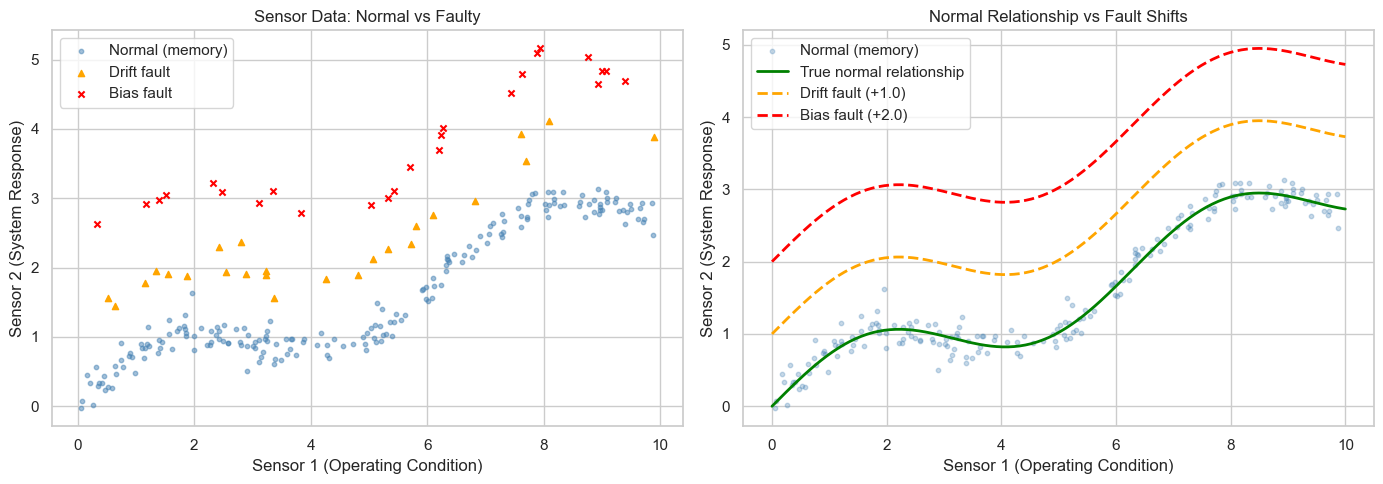

In [5]:
np.random.seed(42)

n_memory = 200
n_normal_test = 100
n_fault_test = 50

def generate_normal_data(n):
    s1 = np.random.uniform(0, 10, n)
    s2 = 0.5 * np.sin(s1) + 0.3 * s1 + np.random.normal(0, 0.15, n)
    return np.column_stack([s1, s2])

X_memory = generate_normal_data(n_memory)

X_normal_test = generate_normal_data(n_normal_test)

s1_fault_drift = np.random.uniform(0, 10, n_fault_test // 2)
s2_fault_drift = 0.5 * np.sin(s1_fault_drift) + 0.3 * s1_fault_drift + 1.0 + np.random.normal(0, 0.15, n_fault_test // 2)
X_fault_drift = np.column_stack([s1_fault_drift, s2_fault_drift])

s1_fault_bias = np.random.uniform(0, 10, n_fault_test // 2)
s2_fault_bias = 0.5 * np.sin(s1_fault_bias) + 0.3 * s1_fault_bias + 2.0 + np.random.normal(0, 0.15, n_fault_test // 2)
X_fault_bias = np.column_stack([s1_fault_bias, s2_fault_bias])

X_fault_test = np.vstack([X_fault_drift, X_fault_bias])

X_all_test = np.vstack([X_normal_test, X_fault_test])
y_all_test = np.array([0] * n_normal_test + [1] * n_fault_test)

print(f"Memory matrix (normal):  {n_memory} observations")
print(f"Normal test set:         {n_normal_test} observations")
print(f"Faulty test set:          {n_fault_test} observations ({n_fault_test // 2} drift + {n_fault_test // 2} bias)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_memory[:, 0], X_memory[:, 1], color="steelblue", s=10, alpha=0.5, label="Normal (memory)")
axes[0].scatter(X_fault_drift[:, 0], X_fault_drift[:, 1], color="orange", s=20, marker="^", label="Drift fault", zorder=3)
axes[0].scatter(X_fault_bias[:, 0], X_fault_bias[:, 1], color="red", s=20, marker="x", label="Bias fault", zorder=3)
axes[0].set_xlabel("Sensor 1 (Operating Condition)")
axes[0].set_ylabel("Sensor 2 (System Response)")
axes[0].set_title("Sensor Data: Normal vs Faulty")
axes[0].legend()

s1_grid = np.linspace(0, 10, 200)
s2_true = 0.5 * np.sin(s1_grid) + 0.3 * s1_grid
axes[1].scatter(X_memory[:, 0], X_memory[:, 1], color="steelblue", s=10, alpha=0.3, label="Normal (memory)")
axes[1].plot(s1_grid, s2_true, color="green", linewidth=2, label="True normal relationship")
axes[1].plot(s1_grid, s2_true + 1.0, color="orange", linewidth=2, linestyle="--", label="Drift fault (+1.0)")
axes[1].plot(s1_grid, s2_true + 2.0, color="red", linewidth=2, linestyle="--", label="Bias fault (+2.0)")
axes[1].set_xlabel("Sensor 1 (Operating Condition)")
axes[1].set_ylabel("Sensor 2 (System Response)")
axes[1].set_title("Normal Relationship vs Fault Shifts")
axes[1].legend()

plt.tight_layout()
plt.show()

## Question 1: Reconstruct Signals with AAKR

The following script extends the AAKR concept to the **multi-dimensional** (auto-associative) case. In `aakr_reconstruct(X_memory, X_query, h)`:
1. For each query observation $\mathbf{x}_q \in \mathbb{R}^2$, computes the **Euclidean distance** to every memory observation: $d_i = \|\mathbf{x}_q - \mathbf{x}_i\|_2$.
2. Computes Gaussian kernel weights and normalizes them (same as Exercise 1).
3. Reconstructs **each sensor** independently using the same weights: $\hat{x}_q^{(j)} = \sum_i \tilde{w}_i \cdot x_i^{(j)}$.

Note: In this function, we are using X to predict reference value of X, i.e., if the machine is OK, what are the values of the sensors we would have observed?

In [6]:
from scipy.spatial.distance import cdist

def aakr_reconstruct(X_memory, X_query, h):
    distances = cdist(X_query, X_memory, metric="euclidean")
    weights = np.exp(-distances**2 / (2 * h**2))
    weights = weights / weights.sum(axis=1, keepdims=True)
    X_reconstructed = weights @ X_memory
    return X_reconstructed

Then:
1. Reconstruct both the normal test data and the faulty test data using the memory matrix with `h=0.5`.
2. Create side-by-side scatter plots showing actual vs reconstructed observations for **normal** and **faulty** data.

Sensor 2 — Normal test MSE:   0.0205
Sensor 2 — Faulty test MSE:   1.7112


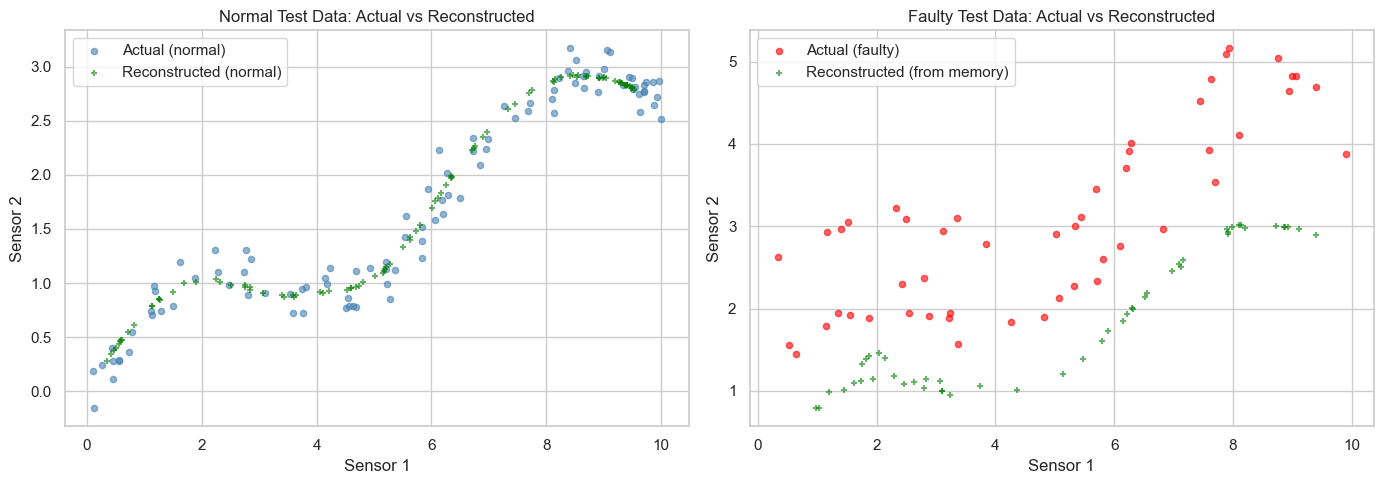

In [7]:
h_fd = 0.5

# Reconstruct X_normal_recon, X_fault_recon based on training data X_memory,
# and the query points X_normal_test and X_fault_test
X_normal_recon = aakr_reconstruct(X_memory, X_normal_test, h_fd)
X_fault_recon = aakr_reconstruct(X_memory, X_fault_test, h_fd)

mse_normal_s2 = np.mean((X_normal_test[:, 1] - X_normal_recon[:, 1])**2)
mse_fault_s2 = np.mean((X_fault_test[:, 1] - X_fault_recon[:, 1])**2)
print(f"Sensor 2 — Normal test MSE:   {mse_normal_s2:.4f}")
print(f"Sensor 2 — Faulty test MSE:   {mse_fault_s2:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_normal_test[:, 0], X_normal_test[:, 1], color="steelblue", s=20,
               alpha=0.6, label="Actual (normal)")
axes[0].scatter(X_normal_recon[:, 0], X_normal_recon[:, 1], color="green", s=20,
               alpha=0.6, marker="+", label="Reconstructed (normal)")
axes[0].set_xlabel("Sensor 1")
axes[0].set_ylabel("Sensor 2")
axes[0].set_title("Normal Test Data: Actual vs Reconstructed")
axes[0].legend()

axes[1].scatter(X_fault_test[:, 0], X_fault_test[:, 1], color="red", s=20,
               alpha=0.6, label="Actual (faulty)")
axes[1].scatter(X_fault_recon[:, 0], X_fault_recon[:, 1], color="green", s=20,
               alpha=0.6, marker="+", label="Reconstructed (from memory)")
axes[1].set_xlabel("Sensor 1")
axes[1].set_ylabel("Sensor 2")
axes[1].set_title("Faulty Test Data: Actual vs Reconstructed")
axes[1].legend()

plt.tight_layout()
plt.show()

Compare the two scatter plots (actual vs reconstructed for Sensor 2).
1. For **normal** data, do the reconstructed points close to the measurements? What does it indictes?
2. For **faulty** data, why do the reconstructed points deviate from the measurements? What does it indictes?

Answer:

1. For normal data the reconstructed points land very close to the actual measurements. This makes sense because the query points come from the same distribution as the memory matrix, so AAKR can find similar observations and reconstruct them accurately. The low MSE confirms this.

2. For faulty data the reconstructed points are systematically lower than the actual measurements. The memory only contains normal behavior, so AAKR always reconstructs what a normal observation would look like. Since the faulty observations are shifted upward by 1 or 2 units, the reconstruction misses them and the gap between actual and reconstructed is what signals the fault.

## Question 2: Residual-Based Fault Detection

Now we use the **residual** between actual and reconstructed signals to detect faults.

1. For each test observation, compute the **residual norm**: $r_q = \|\mathbf{x}_q - \hat{\mathbf{x}}_q\|_2$.
2. Compute residuals for both the normal test set and the faulty test set.
3. Plot **overlaid histograms** of the residual norms for normal (blue) and faulty (red) observations.
4. Set a detection **threshold** using the normal residuals: `threshold = mean(residuals_normal) + 3 * std(residuals_normal)` (the 3-sigma rule).
5. Classify all test observations: if $r_q >$ threshold, predict **fault**; otherwise predict **normal**.
6. Print a **confusion matrix** and compute **accuracy, precision, recall, and F1 score**.
7. Visualize the detection results in the 2D sensor space, coloring each test point by its prediction (TP, TN, FP, FN).

> **Hint:** Compute residuals: `residuals = np.linalg.norm(X_test - X_reconstructed, axis=1)`. For the threshold, use the normal test residuals only. For the confusion matrix, import `confusion_matrix, ConfusionMatrixDisplay` from `sklearn.metrics`. Use `np.where(residuals_all > threshold, 1, 0)` for predictions. For the 2D visualization, color each point based on whether it is a TP, TN, FP, or FN using four different markers/colors.

Detection threshold (3-sigma): 0.5079

Confusion Matrix:
               Pred Normal   Pred Fault
   Actual Norm            99            1
  Actual Fault             0           50

Detection Performance:
  Accuracy:   0.9933
  Precision:  0.9804
  Recall:     1.0000
  F1 Score:   0.9901


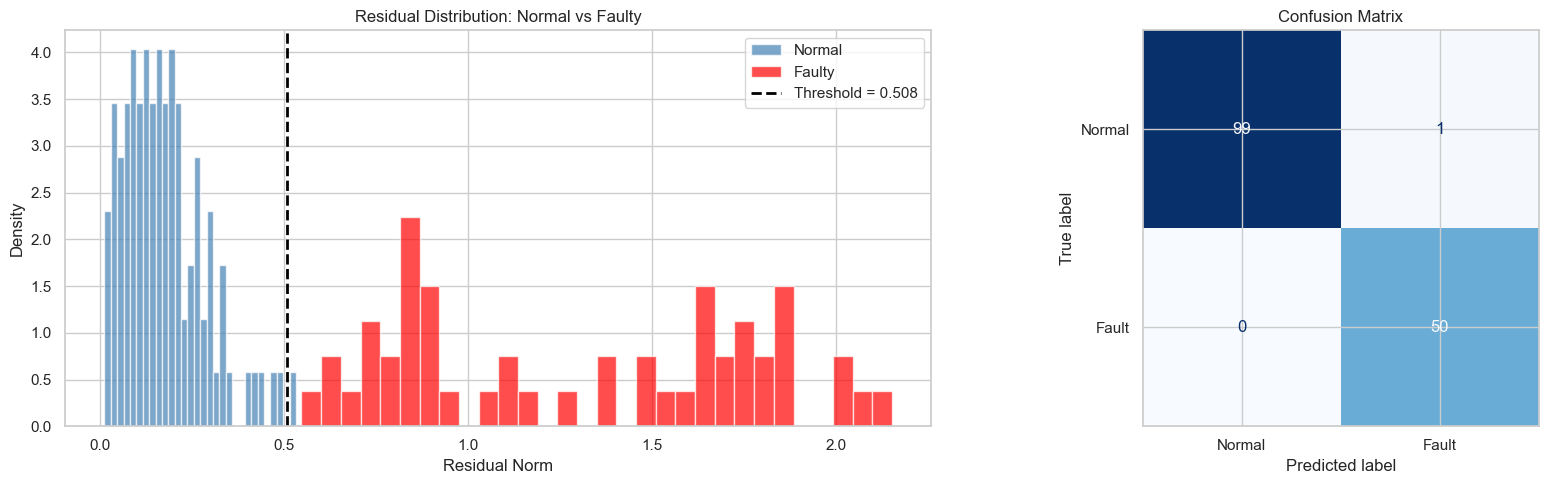

False Positives (FP): 1, False Negatives (FN): 0


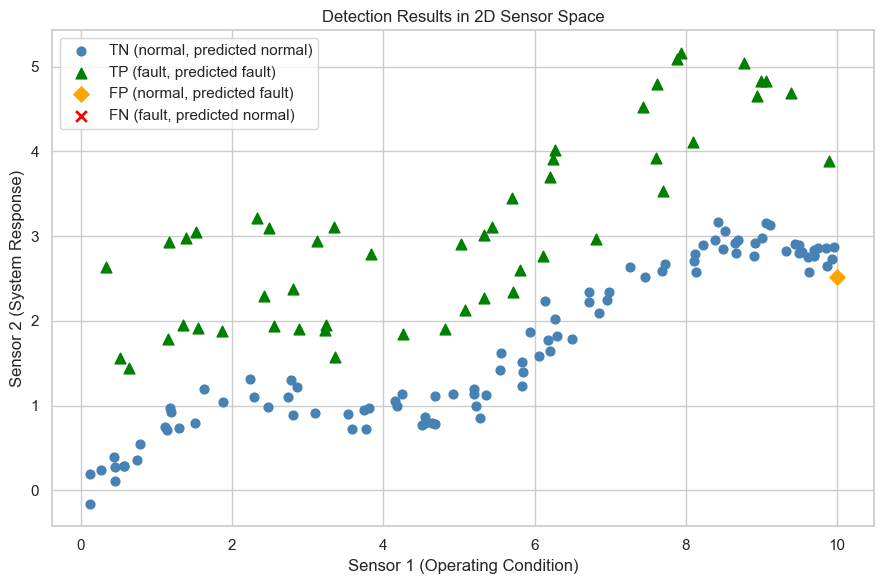

In [8]:
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             accuracy_score, precision_score, recall_score, f1_score)

residuals_normal = np.linalg.norm(X_normal_test - X_normal_recon, axis=1)
residuals_fault = np.linalg.norm(X_fault_test - X_fault_recon, axis=1)
residuals_all = np.concatenate([residuals_normal, residuals_fault])

# Compute the threshold based on 3-sigma rule from the normal residuals
threshold = np.mean(residuals_normal) + 3 * np.std(residuals_normal)
print(f"Detection threshold (3-sigma): {threshold:.4f}")

# Make predictions: Label all samples with residual > threshold as faulty (1), else normal (0)
y_pred_all = np.where(residuals_all > threshold, 1, 0)

cm = confusion_matrix(y_all_test, y_pred_all)
print(f"\nConfusion Matrix:")
print(f"              {'Pred Normal':>12s}  {'Pred Fault':>11s}")
print(f"  {'Actual Norm':>12s}  {cm[0, 0]:>12d}  {cm[0, 1]:>11d}")
print(f"  {'Actual Fault':>12s}  {cm[1, 0]:>12d}  {cm[1, 1]:>11d}")

acc  = accuracy_score(y_all_test, y_pred_all)
prec = precision_score(y_all_test, y_pred_all)
rec  = recall_score(y_all_test, y_pred_all)
f1   = f1_score(y_all_test, y_pred_all)
print(f"\nDetection Performance:")
print(f"  Accuracy:   {acc:.4f}")
print(f"  Precision:  {prec:.4f}")
print(f"  Recall:     {rec:.4f}")
print(f"  F1 Score:   {f1:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

axes[0].hist(residuals_normal, bins=30, color="steelblue", alpha=0.7, label="Normal", density=True)
axes[0].hist(residuals_fault, bins=30, color="red", alpha=0.7, label="Faulty", density=True)
axes[0].axvline(threshold, color="black", linestyle="--", linewidth=2,
               label=f"Threshold = {threshold:.3f}")
axes[0].set_xlabel("Residual Norm")
axes[0].set_ylabel("Density")
axes[0].set_title("Residual Distribution: Normal vs Faulty")
axes[0].legend()

disp = ConfusionMatrixDisplay(cm, display_labels=["Normal", "Fault"])
disp.plot(ax=axes[1], cmap="Blues", colorbar=False)
axes[1].set_title("Confusion Matrix")

plt.tight_layout()
plt.show()

# 2D sensor space: color each test point by TP / TN / FP / FN
tp_mask = (y_all_test == 1) & (y_pred_all == 1)
tn_mask = (y_all_test == 0) & (y_pred_all == 0)
fp_mask = (y_all_test == 0) & (y_pred_all == 1)
fn_mask = (y_all_test == 1) & (y_pred_all == 0)
print(f"False Positives (FP): {fp_mask.sum()}, False Negatives (FN): {fn_mask.sum()}")

fig2, ax2 = plt.subplots(figsize=(9, 6))
ax2.scatter(X_all_test[tn_mask, 0], X_all_test[tn_mask, 1],
            color="steelblue", s=40, label="TN (normal, predicted normal)", zorder=3)
ax2.scatter(X_all_test[tp_mask, 0], X_all_test[tp_mask, 1],
            color="green", s=60, marker="^", label="TP (fault, predicted fault)", zorder=4)
ax2.scatter(X_all_test[fp_mask, 0], X_all_test[fp_mask, 1],
            color="orange", s=60, marker="D", label="FP (normal, predicted fault)", zorder=4)
ax2.scatter(X_all_test[fn_mask, 0], X_all_test[fn_mask, 1],
            color="red", s=60, marker="x", linewidths=2, label="FN (fault, predicted normal)", zorder=4)
ax2.set_xlabel("Sensor 1 (Operating Condition)")
ax2.set_ylabel("Sensor 2 (System Response)")
ax2.set_title("Detection Results in 2D Sensor Space")
ax2.legend()
plt.tight_layout()
plt.show()

Look at the results above.
1. How well do the residual distributions of normal and faulty data separate? Is there overlap?
2. Are there any false alarms (FP) or missed detections (FN)? In a real predictive maintenance scenario, which is more dangerous?
3. If we decrease the values of the thresholds, what happens to the FP and FN? If we increase the values of the thresholds, what happens to the FP and FN?

Answer:

1. The two distributions separate very cleanly. Normal residuals are all below about 0.5 while faulty ones are much larger. There is almost no overlap, which is why the detector works so well here.

2. There is 1 false positive and 0 missed faults. In a real maintenance setting missed faults are more dangerous because a fault that goes undetected can lead to a breakdown or a safety issue. A false alarm just means an unnecessary inspection which is annoying but not critical.

3. If we lower the threshold more observations get flagged, so the number of false positives goes up and missed faults go down. If we raise the threshold fewer observations get flagged, so false positives go down but we start missing more faults. It is always a tradeoff between the two.